# ![Machine Learning Lab](banner.jpg)

# Laboratorio 8 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Carga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab8.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Construir y entrenar una Red Neuronal Convolucional (CNN) para clasificación de imágenes médicas.
2. Aplicar técnicas de preprocesamiento y aumentación de datos a imágenes.
3. Evaluar y comparar el desempeño del modelo con y sin data augmentation.

---

En esta ocasión trabajaremos con el dataset **Brain Tumor MRI Images**, que contiene imágenes de resonancia magnética cerebral clasificadas en 4 categorías: **Glioma**, **Meningioma**, **Pituitary** y **Healthy**.

Dataset: [Brain Tumor MRI Images](https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset/data)

---

## Instrucciones

### 1. Carga y exploración de datos (10%)

1. Descarga el dataset utilizando `kagglehub`:
   ```python
   import kagglehub
   path = kagglehub.dataset_download("miadul/brain-tumor-mri-dataset")
   ```
2. Explora la estructura de carpetas del dataset y cuenta el número de imágenes por clase.
3. Visualiza al menos 3 imágenes de ejemplo de cada clase en una cuadrícula.
4. Muestra la distribución de clases en un gráfico de barras. ¿El dataset está balanceado?

---

### 2. Preprocesamiento de datos (20%)

1. Redimensiona todas las imágenes a un tamaño uniforme (por ejemplo, 150×150 píxeles).
2. Normaliza los valores de los píxeles al rango [0, 1].
3. Divide el dataset en conjuntos de entrenamiento (70%), validación (15%) y prueba (15%). Utiliza `seed = 42`.
4. Crea los datasets de TensorFlow/Keras utilizando `image_dataset_from_directory`.

---

### 3. Modelo CNN base (30%)

1. Construye una CNN con al menos 3 bloques convolucionales (Conv2D + MaxPooling2D).
2. Agrega capas Dense para la clasificación final.
3. Muestra el resumen del modelo (`model.summary()`) e indica el número total de parámetros.
4. Compila el modelo con el optimizador y función de pérdida adecuados para clasificación multiclase.
5. Entrena el modelo.
6. Grafica las curvas de pérdida y precisión (entrenamiento vs validación).

---

### 4. Data Augmentation (30%)

1. Define una estrategia de aumentación de datos que incluya al menos 3 transformaciones (rotación, volteo, zoom, etc.).
2. Visualiza el efecto de la aumentación sobre algunas imágenes de ejemplo.
3. Construye un nuevo modelo CNN que integre las capas de aumentación.
4. Entrena el modelo.
5. Grafica las curvas de aprendizaje del modelo con aumentación.
6. Compara la precisión del modelo con y sin aumentación en el conjunto de prueba.

---

### 5. Análisis de resultados (10%)

1. Genera la matriz de confusión para ambos modelos (con y sin aumentación).
2. ¿Cuáles tipos de tumor son más difíciles de clasificar?
3. Reporta la precisión (accuracy), precisión por clase y recall por clase para el mejor modelo.

---


# **1. Carga y exploración de datos**

In [1]:
import os

os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda-12.8"

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import numpy as np
import kagglehub
import hashlib
import shutil
import random
import os

I0000 00:00:1776357112.168733   30348 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776357112.194040   30348 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776357112.874282   30348 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/nico/Desktop/Assignment-8/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgre

In [3]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Descarga del conjunto de datos a utilizar haciendo uso de la libreria **kagglehub** con el fin de automatizar el proceso y hacer que sea replicable

In [4]:
dataset_path = kagglehub.dataset_download(handle = "miadul/brain-tumor-mri-dataset", output_dir = "../datasets", force_download = True)
print(f"DATASET DOWNLOADED IN: {dataset_path}")

100%|██████████| 236M/236M [00:05<00:00, 49.1MB/s] 

Extracting files...


DATASET DOWNLOADED IN: ../datasets


Exploración de la estructura de carpetas del conjunto de datos descargado anteriormente

In [5]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 2 * level
    folder_name = os.path.basename(root)
    num_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])
    if num_files > 0:
        print(f"{indent}{folder_name}/ ({num_files} imágenes)")
    else:
        print(f"{indent}{folder_name}/")

datasets/
  .complete/
    datasets/
      miadul/
        brain-tumor-mri-dataset/
          1/
  brain_tumor_dataset/
    pituitary/ (1757 imágenes)
    glioma/ (1621 imágenes)
    meningioma/ (1645 imágenes)
    healthy/ (2000 imágenes)


Reorganización de la estructura de carpetas con el fin de facilitar su posterior división y carga 

In [6]:
root_path = "../datasets"
hidden_path = os.path.join(root_path, ".complete")
former_path_classes = os.path.join(root_path, "brain_tumor_dataset")

In [7]:
classes = ["glioma", "healthy", "meningioma", "pituitary"]

In [8]:
if os.path.exists(hidden_path):
    shutil.rmtree(hidden_path)
    print(f"Folder '{hidden_path}' deleted")

for name in classes:
    origin = os.path.join(former_path_classes, name)
    destination = os.path.join(root_path, name)
    
    if os.path.exists(origin):
        shutil.move(origin, destination)
        print(f"☑ Class '{name}' moved to root")

if os.path.exists(former_path_classes):
    shutil.rmtree(former_path_classes)
    print(f"Intermediate folder '{former_path_classes}' deleted")

Folder '../datasets/.complete' deleted
☑ Class 'glioma' moved to root
☑ Class 'healthy' moved to root
☑ Class 'meningioma' moved to root
☑ Class 'pituitary' moved to root
Intermediate folder '../datasets/brain_tumor_dataset' deleted


Verificación de la nueva estructura de carpetas del conjunto de datos

In [9]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 2 * level
    folder_name = os.path.basename(root)
    num_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])
    if num_files > 0:
        print(f"{indent}{folder_name}/ ({num_files} imágenes)")
    else:
        print(f"{indent}{folder_name}/")

datasets/
  pituitary/ (1757 imágenes)
  glioma/ (1621 imágenes)
  meningioma/ (1645 imágenes)
  healthy/ (2000 imágenes)


Eliminación de las imágenes repetidas haciendo uso de comparación mediante **códigos de hash**

In [10]:
found_hashes = set()
counter = 0

In [11]:
for root, dirs, files in os.walk(root_path):
    for filename in files:

        if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            file_path = os.path.join(root, filename)
            
            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            
            if file_hash in found_hashes:
                print(f"Deleting duplicate: {file_path}")
                os.remove(file_path)
                counter += 1
            else:
                found_hashes.add(file_hash)

Deleting duplicate: ../datasets/pituitary/0196.jpg
Deleting duplicate: ../datasets/pituitary/0478.jpg
Deleting duplicate: ../datasets/pituitary/0278.jpg
Deleting duplicate: ../datasets/pituitary/0496.jpg
Deleting duplicate: ../datasets/pituitary/1753.jpg
Deleting duplicate: ../datasets/pituitary/0904.jpg
Deleting duplicate: ../datasets/pituitary/1058.jpg
Deleting duplicate: ../datasets/pituitary/0900.jpg
Deleting duplicate: ../datasets/pituitary/0110.jpg
Deleting duplicate: ../datasets/pituitary/1110.jpg
Deleting duplicate: ../datasets/pituitary/1593.jpg
Deleting duplicate: ../datasets/pituitary/0951.jpg
Deleting duplicate: ../datasets/pituitary/0306.jpg
Deleting duplicate: ../datasets/pituitary/1735.jpg
Deleting duplicate: ../datasets/pituitary/1055.jpg
Deleting duplicate: ../datasets/pituitary/0350.jpg
Deleting duplicate: ../datasets/pituitary/0369.jpg
Deleting duplicate: ../datasets/glioma/1579.jpg
Deleting duplicate: ../datasets/meningioma/0834.jpg
Deleting duplicate: ../datasets/m

In [12]:
print(f"NUMVER OF PRESERVED IMAGES: {len(found_hashes)}")
print(f"NUMBER OF DELETED IMAGES: {counter}")

NUMVER OF PRESERVED IMAGES: 6597
NUMBER OF DELETED IMAGES: 426


Visualización de 4 imágenes aleatorias por cada clase del conjunto de datos

In [13]:
data_dir = Path("../datasets") 
classes = ["glioma", "healthy", "meningioma", "pituitary"]

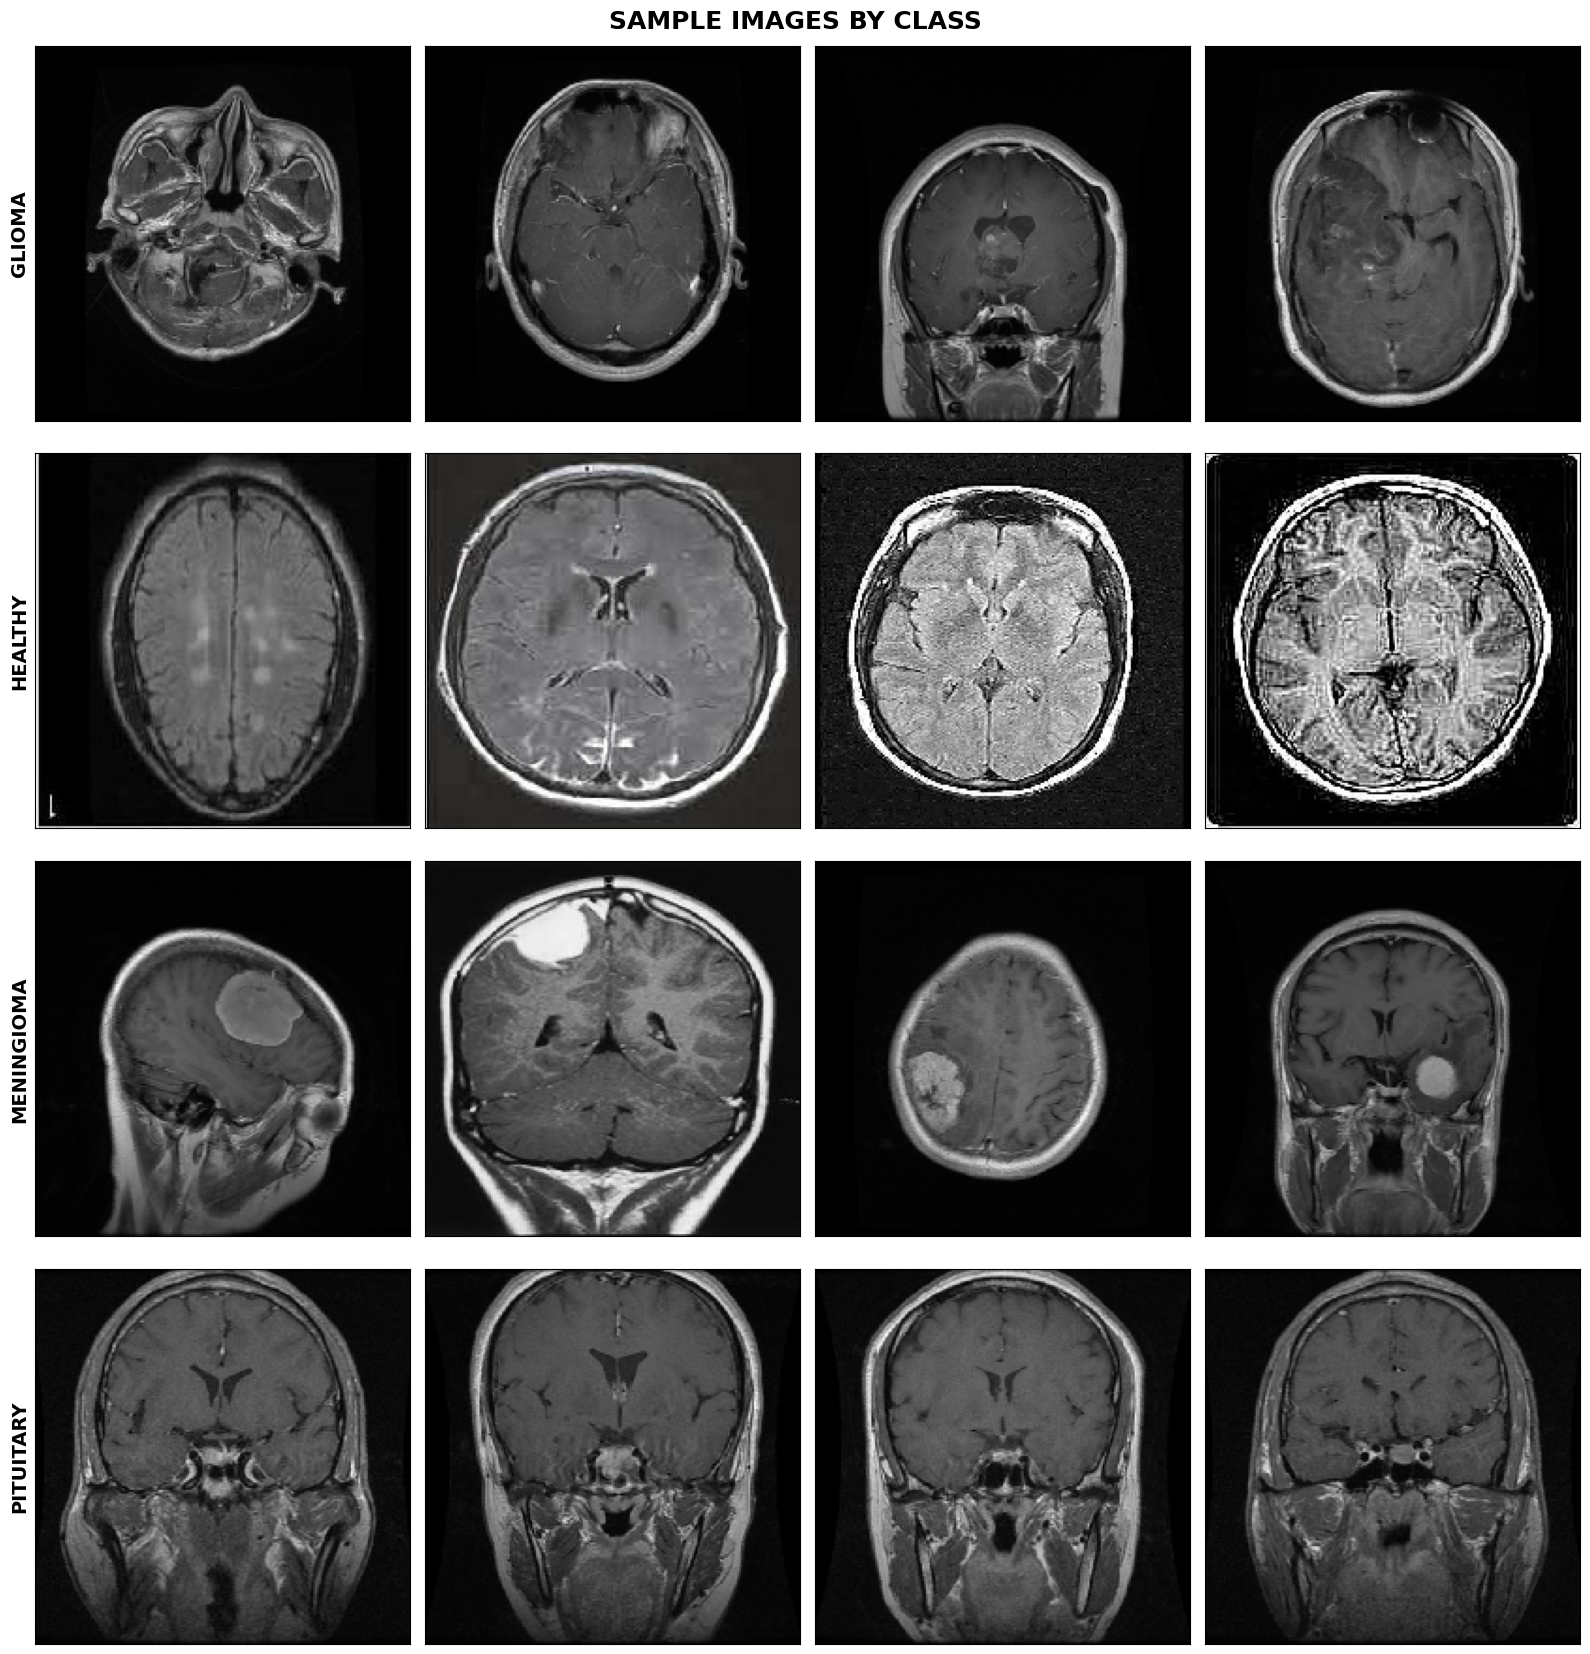

In [14]:
fig, axes = plt.subplots(4, 4, figsize = (16, 17))

for row, class_name in enumerate(classes):

    class_dir = data_dir / class_name
    image_files = list(class_dir.glob("*.jpg"))
    samples = random.sample(image_files, 4)
    
    for col, img_path in enumerate(samples):

        ax = axes[row, col]
        img = tf.keras.utils.load_img(img_path, target_size = (200, 200))
        ax.imshow(img)
        
        if col == 0:
            ax.set_ylabel(class_name.upper(), fontsize = 14, fontweight = "bold")
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("SAMPLE IMAGES BY CLASS", fontsize = 18, fontweight = "bold")
plt.tight_layout()
plt.show()

Conteo de la cantidad de imágenes asociadas a cada clase del conjunto de datos

In [15]:
counts = []

for name in classes:
    class_path = os.path.join(data_dir, name)
    n_images = len(os.listdir(class_path))
    counts.append(n_images)
    print(f"Class {name}: {n_images} images")

Class glioma: 1620 images
Class healthy: 1706 images
Class meningioma: 1531 images
Class pituitary: 1740 images


Visualización de los conteos obtenidos anteriormente en forma de gráfico de barras

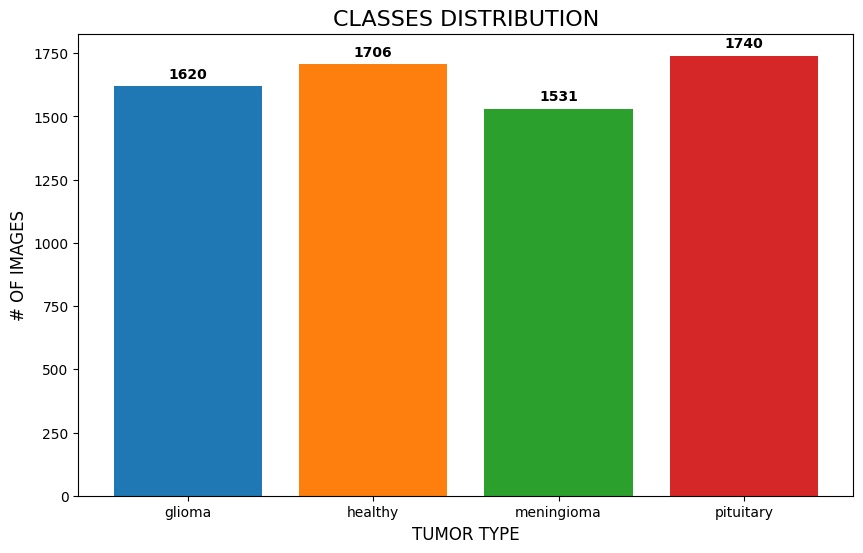

In [16]:
plt.figure(figsize = (10, 6))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"] 
bars = plt.bar(classes, counts, color = colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, yval, ha = "center", va = "bottom", fontweight = "bold")

plt.title("CLASSES DISTRIBUTION", fontsize = 16)
plt.xlabel("TUMOR TYPE", fontsize = 12)
plt.ylabel("# OF IMAGES", fontsize = 12)

plt.show()

|**Pregunta**|**Respuesta**|
|---|---|
|¿El conjunto de datos está balanceado?|Sí, el conjunto de datos está relativamente balanceado, ya que las cuatro clases mantienen una proporción similar (entre el 23% y el 28.5% del total). Sin embargo, es muy recomendable implementar técnicas de Data Augmentation (como rotaciones, zooms o ajustes de brillo). Esto permite compensar las ligeras diferencias numéricas entre categorías, equilibrando mejor el peso de cada clase durante el entrenamiento y mejorando la capacidad del modelo para generalizar ante casos nuevos.|

# **2. Preprocesamiento de datos**

In [17]:
import splitfolders

División de las imágenes en conjuntos de datos para entrenamiento, validación y prueba. Se decide hacer división mediante el sistema de archivos con el fin de añadir complejidad al proceso y evitar fugas de datos

In [18]:
splitfolders.ratio("../datasets", output = "../dataset_split", 
                   seed = SEED, ratio=(.7, .15, .15), 
                   group_prefix = None, move = False) 

Copying files: 6597 files [00:00, 26750.39 files/s]


Carga de las imágenes pertenecientes a las distintas clases haciendo uso de la función **image_dataset_from_directory**. Al cargar las imágenes, todas son redimensionadas a un tamaño de **150x150** píxeles y se crean batchs de **32** imágenes cada uno

In [19]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [20]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "../dataset_split/train",
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True  
)

Found 4617 files belonging to 4 classes.


W0000 00:00:1776357121.685291   30348 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776357121.689190   30348 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776357121.781651   30348 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8888 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "../dataset_split/val",
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False 
)

Found 988 files belonging to 4 classes.


In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../dataset_split/test",
    label_mode = "categorical",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False 
)

Found 992 files belonging to 4 classes.


Verificación de que la función identifica correctamente las clases de las imágenes a partir de la estructura de directorios del conjunto de datos

In [23]:
class_names = train_ds.class_names
print(f"LOADED CLASSES: {class_names}")

LOADED CLASSES: ['glioma', 'healthy', 'meningioma', 'pituitary']


Normalización de las imágenes en la totalidad de los conjuntos de datos creados del rango **[0, 255]** al rango **[0 , 1]**

In [24]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [25]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Optimización de los conjuntos de datos para aprovechar la carga de las imágenes en **RAM** y reducir el número de lecturas a realizar sobre el disco del sistema

In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

Evaluación de la estructura final de los conjuntos de datos creados

In [27]:
print(f"BATCHES:\n")
print(f"TRAIN: {train_ds.cardinality().numpy()}")
print(f"VALIDATION: {val_ds.cardinality().numpy()}")
print(f"TEST: {test_ds.cardinality().numpy()}")

BATCHES:

TRAIN: 145
VALIDATION: 31
TEST: 31


# **3. Modelo CNN base**

In [28]:
from tensorflow.keras import layers, models

Se definen las constantes asociadas a las dimensiones de las imágenes que se alimentaran a la CNN. De igual forma, se define el número de clases de salida para definir la última capa del modelo

In [29]:
IMG_HEIGHT = 150 
IMG_WIDTH = 150

num_classes = 4

Se construye una red neuronal secuencial haciendo uso de 3 capas convolucionales, una capa encargada de aplanar los resultados de la última capa convolucional y dos capas densas, encargadas de llevar a cabo el proceso de clasificación final. Cabe resaltar que tambień se añade una capa de dropout fuerte al final de la arquitectura para reducir el overfitting

In [30]:
model = models.Sequential([
    
    layers.Conv2D(16, (3, 3), activation = "relu", input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5), 
    
    layers.Dense(num_classes, activation = "softmax") 
])

/home/nico/Desktop/Assignment-8/env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Se muestra el resumen del modelo, el cual presenta la arquitectura construida y el número total de parámetros (discriminando a su vez por parámetros entrenables, que en este caso es igual al número total de parámetros)

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,207,652 (4.61 MB)

 Trainable params: 1,207,652 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

El modelo se compilar utilizando el optimizador **adam**, el cual corresponde al estado del arte y es el más robusto para este tipo de tareas. De igual forma, se utiliza como función de perdida a la función **Categorical Crossentropy**, la cual permite medir la perdida en problemas de clasificación multiclase. Se utiliza como métrica el **accuracy** ya que las clases están relativamente balanceadas

In [32]:
model.compile(optimizer = "adam",
            loss = tf.keras.losses.CategoricalCrossentropy(from_logits = False),
            metrics = ["accuracy"])

Se lleva a cabo el entrenamiento del modelo por **15 épocas**

In [33]:
history = model.fit(
    train_ds,           
    validation_data = val_ds,
    epochs = 15,        
    verbose = 1
)

Epoch 1/15


I0000 00:00:1776357123.441172   30678 service.cc:153] XLA service 0x70fc980073d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776357123.441194   30678 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1776357123.490189   30678 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776357123.597381   30678 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1776357123.617210   30678 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2200__.44
I0000 00:00:1776357124.427201   30838 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 16 bytes spill stores, 16 bytes spill loads



 28/145 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3715 - loss: 1.3264

I0000 00:00:1776357126.534743   30678 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


134/145 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5390 - loss: 1.0361

I0000 00:00:1776357127.547598   30678 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2200__.44
I0000 00:00:1776357127.705383   31080 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776357127.726537   31068 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 28 bytes spill stores, 28 bytes spill loads

I0000 00:00:1776357127.766657   31069 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads



145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6580 - loss: 0.8103 - val_accuracy: 0.8310 - val_loss: 0.4690
Epoch 2/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7945 - loss: 0.5244 - val_accuracy: 0.8512 - val_loss: 0.3912
Epoch 3/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8230 - loss: 0.4404 - val_accuracy: 0.8451 - val_loss: 0.3581
Epoch 4/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8545 - loss: 0.3700 - val_accuracy: 0.8988 - val_loss: 0.2768
Epoch 5/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8770 - loss: 0.3106 - val_accuracy: 0.8694 - val_loss: 0.3120
Epoch 6/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8917 - loss: 0.2586 - val_accuracy: 0.8927 - val_loss: 0.2730
Epoch 7/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9023 - loss: 0.2436 - val_accuracy: 0.8765 - val_loss: 0.2715
Epoch 8/15
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9201 - loss: 0.2006 - val_accuracy: 0.9059 - val

Se visualizan las curvas de entrenamiento para evaluar el proceso del modelo

In [34]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

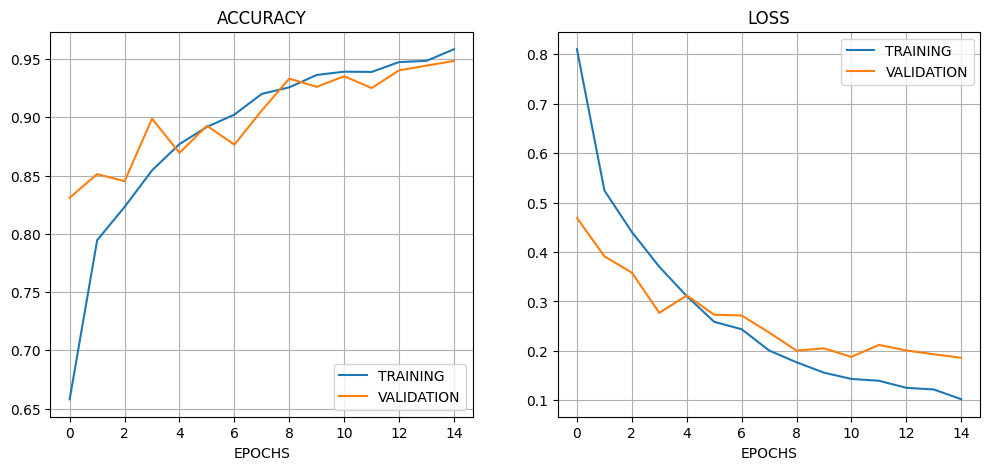

In [35]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label = "TRAINING")
plt.plot(epochs_range, val_acc, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = "TRAINING")
plt.plot(epochs_range, val_loss, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()

Finalmente, se calculan las métricas básicas (**loss** y **accuracy**) sobre el conjunto de prueba haciendo uso del modelo CNN base

In [36]:
results = model.evaluate(test_ds)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9456 - loss: 0.3071


In [37]:
print(f"LOSS IN TEST: {results[0]:.4f}")
print(f"ACCURACY IN TEST: {results[1]:.4f}")

LOSS IN TEST: 0.3071
ACCURACY IN TEST: 0.9456


# **4. Data Augmentation**

Definición de la estrategia que se va a utilizar para la aumentación de datos. Se decide utilizar volteos o **flips horizontales y verticales**, **rotación aleatorias de hasta un 20%** con respecto a la imágnen original y **zoom aleatorio**. Para mejorar el rendimiento del proceso de aumentación, se utilizar las capas de aumentación de **tensorflow**, las cuales aprovechan la ejecución en GPU

In [38]:
data_augmentation = models.Sequential([

  layers.RandomFlip("horizontal_and_vertical"), 

  layers.RandomRotation(0.1),  

  layers.RandomZoom(0.1),   
                     
])

Para verificar que las transformaciones tienen sentido y se están aplicando correctamente, se visualizan 8 procesos de aumentación sobre una misma imágen. De esta forma se puede verificar que no se pierda información y las imágenes continuen teniendo sentido

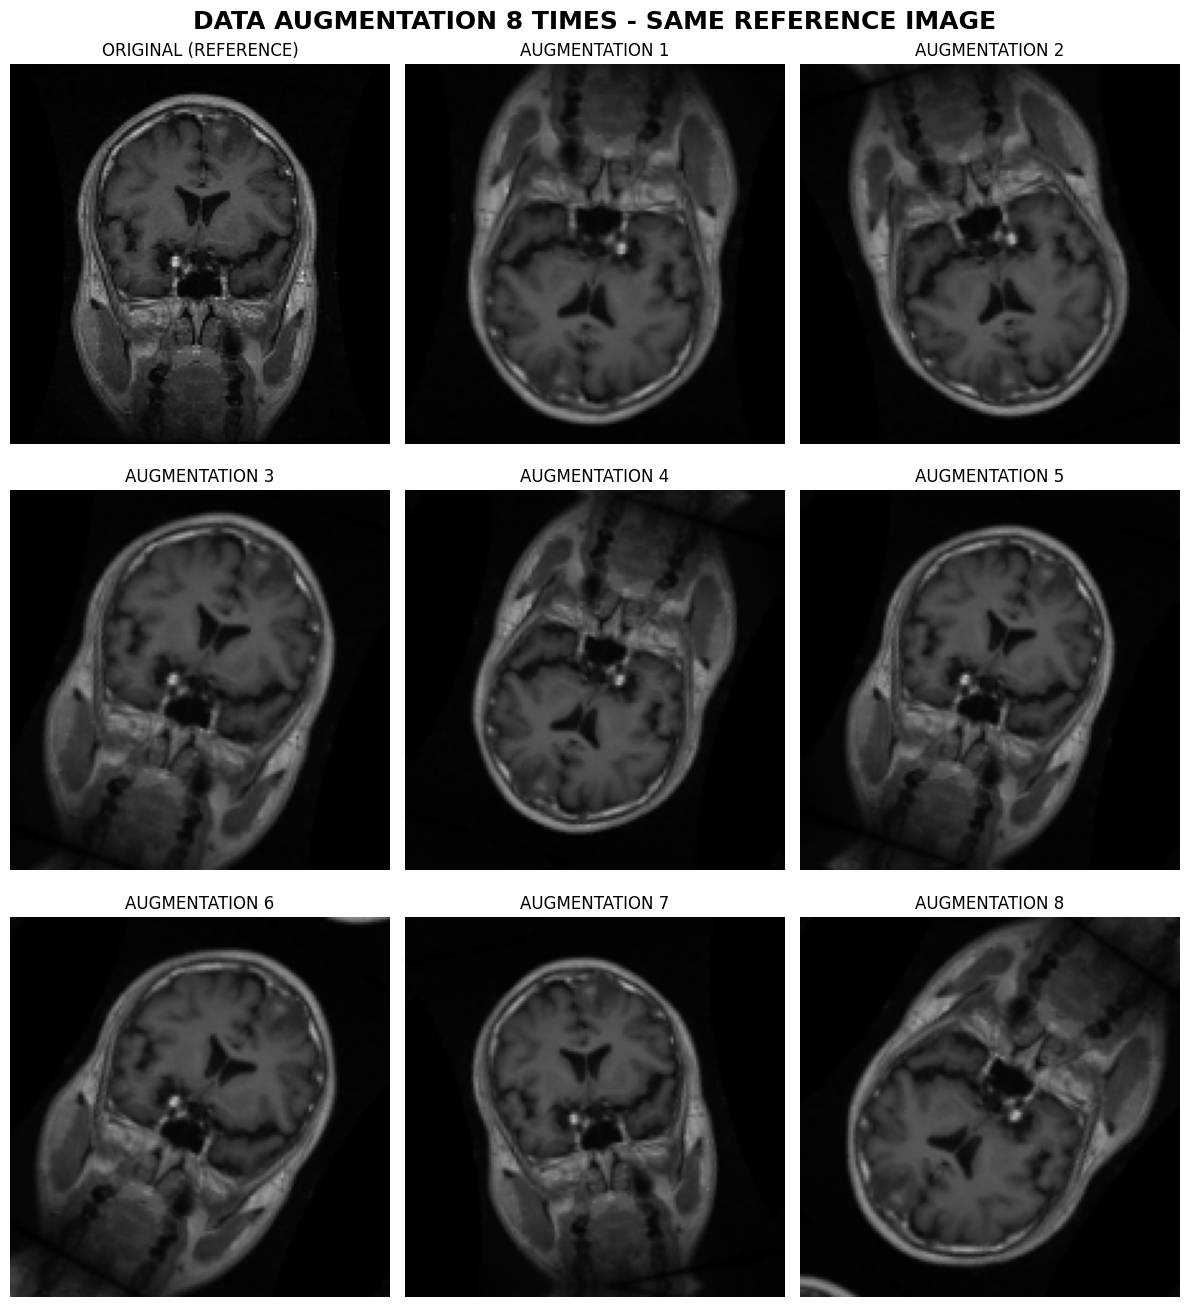

In [39]:
for images, labels in train_ds.take(1):

    plt.figure(figsize = (12, 13.5))
    
    first_image = images[0]
    
    for i in range(9): 

        ax = plt.subplot(3, 3, i + 1)
        
        if i == 0:
    
            img_to_show = first_image.numpy()
            plt.title("ORIGINAL (REFERENCE)")

        else:
            
            augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training = True)
            img_to_show = augmented_image[0].numpy()
            plt.title(f"AUGMENTATION {i}")
        
        img_to_show = np.clip(img_to_show, 0, 1)
        plt.imshow(img_to_show)
        plt.axis("off")

plt.suptitle("DATA AUGMENTATION 8 TIMES - SAME REFERENCE IMAGE", fontsize = 18, fontweight = "bold")
plt.tight_layout()
plt.show()

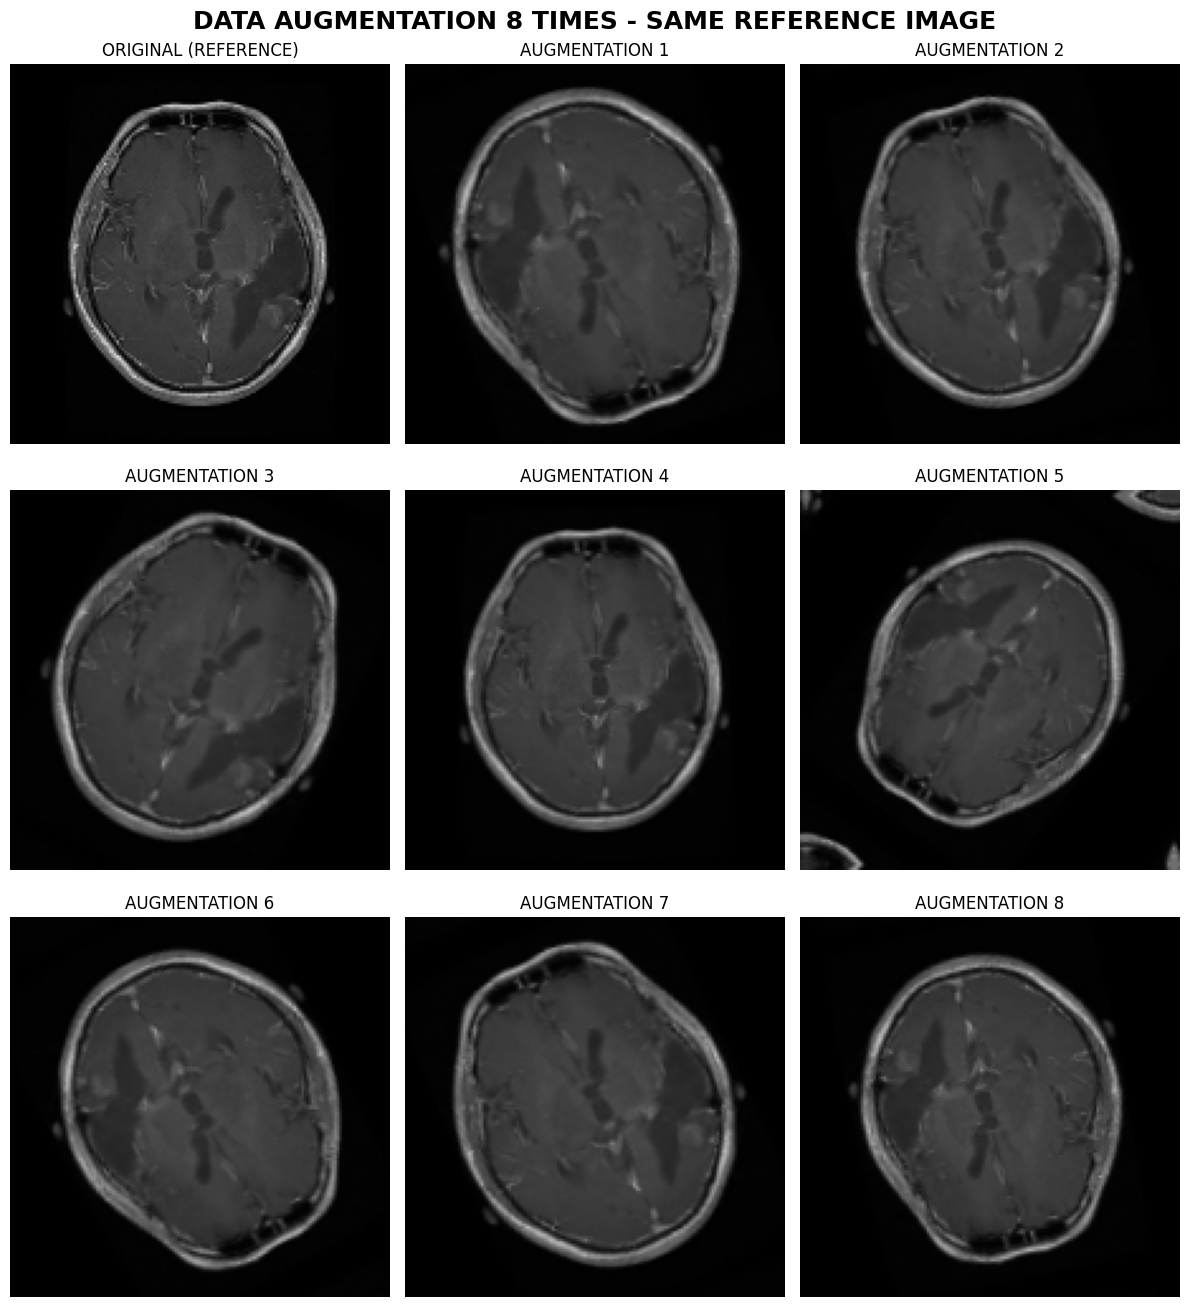

In [40]:
for images, labels in train_ds.take(1):

    plt.figure(figsize = (12, 13.5))
    
    first_image = images[5]
    
    for i in range(9): 

        ax = plt.subplot(3, 3, i + 1)
        
        if i == 0:
    
            img_to_show = first_image.numpy()
            plt.title("ORIGINAL (REFERENCE)")

        else:
            
            augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training = True)
            img_to_show = augmented_image[0].numpy()
            plt.title(f"AUGMENTATION {i}")
        
        img_to_show = np.clip(img_to_show, 0, 1)
        plt.imshow(img_to_show)
        plt.axis("off")

plt.suptitle("DATA AUGMENTATION 8 TIMES - SAME REFERENCE IMAGE", fontsize = 18, fontweight = "bold")
plt.tight_layout()
plt.show()

Construcción del nuevo modelo de arquitectura CNN integrando las capas de aumentación de imágenes. La arquitectura del modelo, en general, es la misma. Solo se añaden las capas de aumentación al principio del modelo

In [41]:
model_augmented = models.Sequential([
    
    data_augmentation,
    
    layers.Conv2D(16, (3, 3), activation = "relu", input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),

    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.5), 
    
    layers.Dense(num_classes, activation = "softmax") 
])

Los parámetros compilación son los mismos que los usados en el modelo CNN base

In [42]:
model_augmented.compile(optimizer = "adam",
            loss = tf.keras.losses.CategoricalCrossentropy(from_logits = False),
            metrics = ["accuracy"])

Se lleva a cabo el entrenamiento del modelo con aumentación de datos por **30 épocas**. Se le dan más épocas a este modelo ya que tiene más datos de entrenamiento y estos son más variados

In [43]:
history_augmented = model_augmented.fit(
    train_ds,           
    validation_data = val_ds,
    epochs = 30,        
    verbose = 1
)

Epoch 1/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5356 - loss: 1.0523 - val_accuracy: 0.4909 - val_loss: 1.1369
Epoch 2/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6786 - loss: 0.7950 - val_accuracy: 0.6802 - val_loss: 0.7529
Epoch 3/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7208 - loss: 0.7112 - val_accuracy: 0.6660 - val_loss: 0.7988
Epoch 4/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7293 - loss: 0.6854 - val_accuracy: 0.7257 - val_loss: 0.6547
Epoch 5/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7377 - loss: 0.6549 - val_accuracy: 0.7308 - val_loss: 0.6415
Epoch 6/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7611 - loss: 0.6074 - val_accuracy: 0.7308 - val_loss: 0.6439
Epoch 7/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7685 - loss: 0.5840 - val_accuracy: 0.7652 - val_loss: 0.5870
Epoch 8/30
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7804 - loss: 0.5649 - val_accuracy: 0.

Se visualizan las curvas de entrenamiento para evaluar el proceso del modelo

In [44]:
acc_aug = history_augmented.history["accuracy"]
val_acc_aug = history_augmented.history["val_accuracy"]
loss_aug = history_augmented.history["loss"]  
val_loss_aug = history_augmented.history["val_loss"]

epochs_range_aug = range(len(acc_aug))

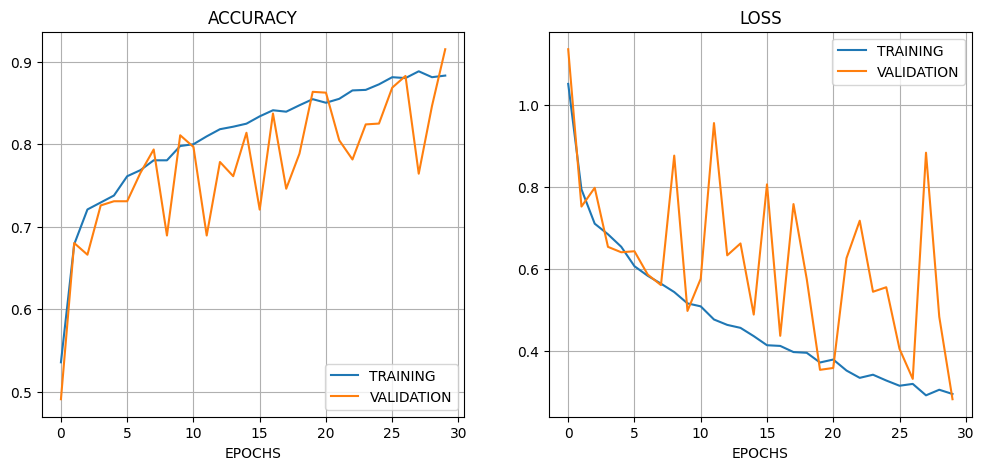

In [45]:
plt.figure(figsize = (12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_aug, acc_aug, label = "TRAINING")
plt.plot(epochs_range_aug, val_acc_aug, label = "VALIDATION")
plt.title("ACCURACY")
plt.xlabel("EPOCHS")
plt.legend(loc = "lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_aug, loss_aug, label = "TRAINING")
plt.plot(epochs_range_aug, val_loss_aug, label = "VALIDATION")
plt.title("LOSS")
plt.xlabel("EPOCHS")
plt.legend(loc = "upper right")
plt.grid(True)

plt.show()

Finalmente, se calculan las métricas básicas (**loss** y **accuracy**) sobre el conjunto de prueba haciendo uso del modelo CNN base

In [46]:
results_aug = model_augmented.evaluate(test_ds)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9012 - loss: 0.2780


In [47]:
print(f"LOSS IN TEST: {results_aug[0]:.4f}")
print(f"ACCURACY IN TEST: {results_aug[1]:.4f}")

LOSS IN TEST: 0.2780
ACCURACY IN TEST: 0.9012


# **5. Análisis de resultados**

In [54]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Para construir la matriz de confusión de ambos modelos y llevar a cabo una evaluación más detalladas, se especifican las clases y se obtienen las etiquetas reales del conjunto de prueba

In [51]:
classes = ["glioma", "healthy", "meningioma", "pituitary"]

In [ ]:
y_true = np.concatenate([y for x, y in test_ds], axis = 0)
y_true_indices = np.argmax(y_true, axis = 1)

Se define una función para repetir el proceso de evaluación en ambos modelos

In [55]:
def evaluate_model(model, name):

    preds = model.predict(test_ds)
    y_pred_indices = np.argmax(preds, axis=1)
    
    cm = confusion_matrix(y_true_indices, y_pred_indices)
    
    plt.figure(figsize = (9, 7))
    
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = classes, yticklabels = classes)
    
    plt.title(f"CONFUSION MATRIX - {name}")
    plt.ylabel("REAL DIAGNOSIS")
    plt.xlabel("MODEL DIAGNOSIS")
    plt.show()
    
    print(f"\nCLASSIFICATION REPORT - {name}:")
    print(classification_report(y_true_indices, y_pred_indices, target_names = classes))

Se lleva a cabo la evaluación para ambos modelos

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


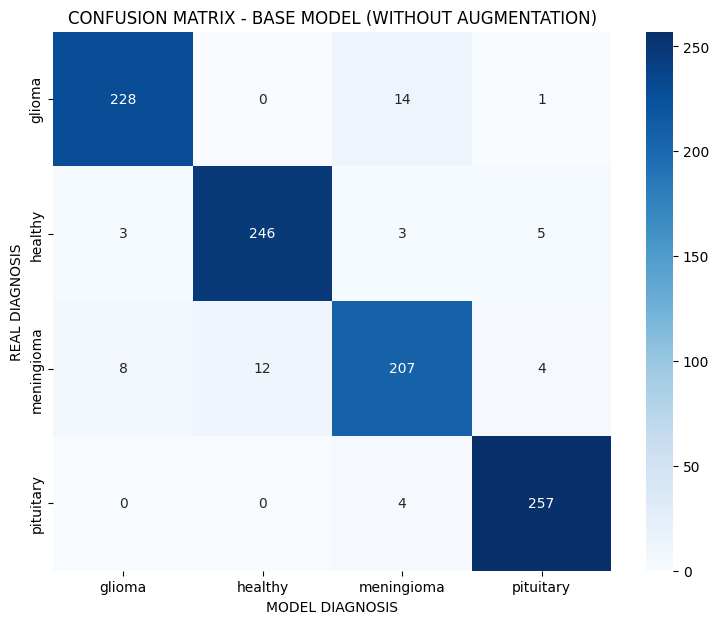


CLASSIFICATION REPORT - BASE MODEL (WITHOUT AUGMENTATION):
              precision    recall  f1-score   support

      glioma       0.95      0.94      0.95       243
     healthy       0.95      0.96      0.96       257
  meningioma       0.91      0.90      0.90       231
   pituitary       0.96      0.98      0.97       261

    accuracy                           0.95       992
   macro avg       0.94      0.94      0.94       992
weighted avg       0.95      0.95      0.95       992



In [56]:
evaluate_model(model, "BASE MODEL (WITHOUT AUGMENTATION)")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


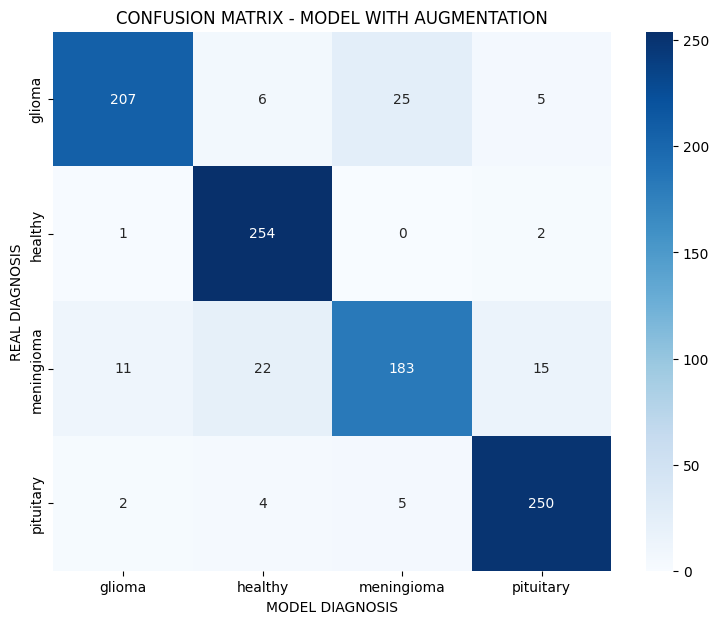


CLASSIFICATION REPORT - MODEL WITH AUGMENTATION:
              precision    recall  f1-score   support

      glioma       0.94      0.85      0.89       243
     healthy       0.89      0.99      0.94       257
  meningioma       0.86      0.79      0.82       231
   pituitary       0.92      0.96      0.94       261

    accuracy                           0.90       992
   macro avg       0.90      0.90      0.90       992
weighted avg       0.90      0.90      0.90       992



In [57]:
evaluate_model(model_augmented, "MODEL WITH AUGMENTATION")

|**Pregunta**|**Respuesta**|
|---|---|
|¿Cúal modelo logra el mejor rendimiento?|El **modelo base**, con una **precisión global (Accuracy) del 95%**. Supera al modelo con aumentación en todas las métricas clave (F1-score, Precision y Recall), demostrando un aprendizaje eficiente y estable de las características de las imágenes|
|¿Cuáles tipos de tumor son más dificiles de clasificar?|El **Meningioma**. Es la clase con el rendimiento más bajo en ambos modelos. En el modelo base tiene un Recall de 0.90, y en el de aumentación baja a 0.79, siendo el tipo de tumor que más confusión genera para la red. Luego del **meningioma**, el siguiente tumor más difícil de clasificar es el **Glioma**|
|¿Cuales son las métricas del mejor modelo?|Se reporta un **Accuracy Global de 95%**. El desglose detallado por clase (Precisión / Recall) es: **Glioma** (0.95 / 0.94), **Healthy** (0.95 / 0.96), **Meningioma** (0.91 / 0.90) y **Pituitary** (0.96 / 0.98)|